In [103]:
# TASK 2: LINEAR & MULTIVARIABLE REGRESSION - HOUSE PRICE PREDICTION

# --- STEP 1: Import libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [105]:
# --- STEP 2: Load dataset ---
CSV_PATH = "RealEstateAgencyData.csv"
df = pd.read_csv(CSV_PATH)
print("\nDataset Loaded Successfully\n")
print(df.head())




Dataset Loaded Successfully

   PropertyID PropertyType     Location  Size_sqm  PriceUSD
0           1    Warehouse     New York       289    933123
1           2        Villa        Miami       412    919739
2           3        Villa     New York       213    597561
3           4        Villa  Los Angeles        88    227159
4           5       Retail     New York       485    593105


In [107]:
# --- STEP 3: EDA & Preprocessing ---
print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

print("\nMissing Values:\n", df.isnull().sum())

# Encode categorical features
df_encoded = pd.get_dummies(df, columns=['PropertyType', 'Location'], drop_first=True)


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PropertyID    1000 non-null   int64 
 1   PropertyType  1000 non-null   object
 2   Location      1000 non-null   object
 3   Size_sqm      1000 non-null   int64 
 4   PriceUSD      1000 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 39.2+ KB
None

--- Summary Statistics ---
        PropertyID     Size_sqm       PriceUSD
count  1000.000000  1000.000000    1000.000000
mean    500.500000   266.800000  520742.562000
std     288.819436   128.249803  278213.721261
min       1.000000    50.000000   51696.000000
25%     250.750000   158.750000  272553.750000
50%     500.500000   254.000000  521777.000000
75%     750.250000   374.500000  760105.250000
max    1000.000000   500.000000  998279.000000

Missing Values:
 PropertyID      0
PropertyType    0
Location        0



--- Single-variable Linear Regression (PriceUSD vs Size_sqm) ---
Coefficient (Slope): 49.13
Intercept: 511172.43
RMSE: 276288.63
R²: -0.0028


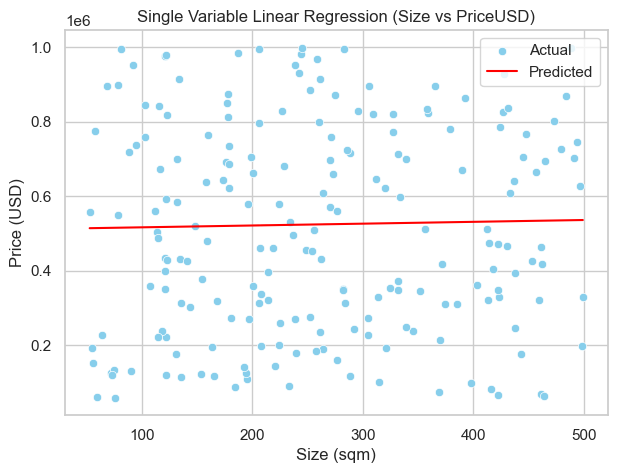

In [109]:
# --- STEP 4: Single-variable Linear Regression (Size vs Price) ---
print("\n--- Single-variable Linear Regression (PriceUSD vs Size_sqm) ---")

X_single = df_encoded[['Size_sqm']]
y = df_encoded['PriceUSD']

X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

model_single = LinearRegression()
model_single.fit(X_train, y_train)
y_pred_single = model_single.predict(X_test)

rmse_single = np.sqrt(metrics.mean_squared_error(y_test, y_pred_single))
r2_single = metrics.r2_score(y_test, y_pred_single)

print(f"Coefficient (Slope): {model_single.coef_[0]:.2f}")
print(f"Intercept: {model_single.intercept_:.2f}")
print(f"RMSE: {rmse_single:.2f}")
print(f"R²: {r2_single:.4f}")

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_test['Size_sqm'], y=y_test, label="Actual", color="skyblue")
sns.lineplot(x=X_test['Size_sqm'], y=y_pred_single, color='red', label="Predicted")
plt.title("Single Variable Linear Regression (Size vs PriceUSD)")
plt.xlabel("Size (sqm)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


--- Multivariable Linear Regression ---
                         Coefficient
Size_sqm                   34.918142
PropertyType_Office     53347.123545
PropertyType_Retail     34719.349512
PropertyType_Villa      31312.281381
PropertyType_Warehouse  26855.071774
Location_Houston         2724.461785
Location_Los Angeles   -42598.906693
Location_Miami           4677.770336
Location_New York      -31896.599245

Intercept: 500118.76
RMSE: 281666.99
R²: -0.0423


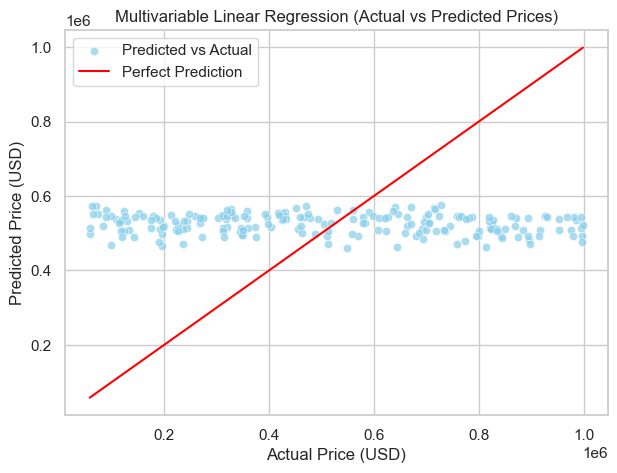

In [121]:
# --- STEP 5: Multivariable Linear Regression ---
print("\n--- Multivariable Linear Regression ---")

# Exclude ID column and target
X_multi = df_encoded.drop(columns=['PropertyID', 'PriceUSD'])
y = df_encoded['PriceUSD']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

rmse_multi = np.sqrt(metrics.mean_squared_error(y_test, y_pred_multi))
r2_multi = metrics.r2_score(y_test, y_pred_multi)

# Display coefficients
coeff_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=['Coefficient'])
print(coeff_df)
print(f"\nIntercept: {model_multi.intercept_:.2f}")
print(f"RMSE: {rmse_multi:.2f}")
print(f"R²: {r2_multi:.4f}")

# --- Visualization: Actual vs Predicted Prices ---
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred_multi, color="skyblue", alpha=0.7, label="Predicted vs Actual")
sns.lineplot(x=y_test, y=y_test, color="red", label="Perfect Prediction")
plt.title("Multivariable Linear Regression (Actual vs Predicted Prices)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.show()


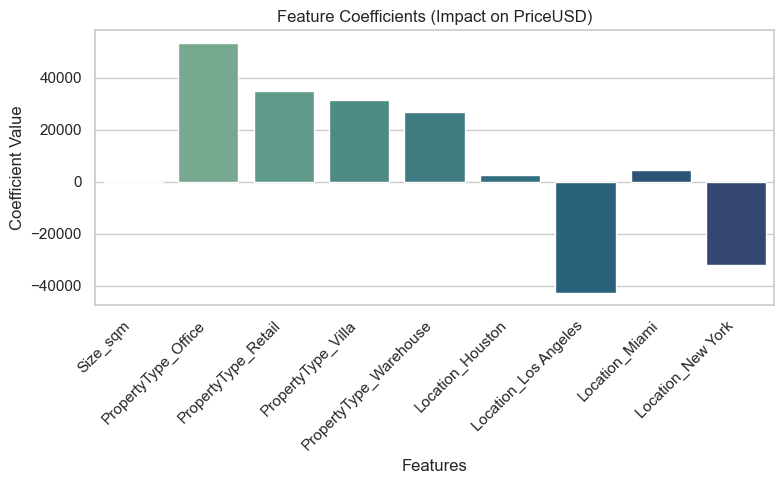

In [113]:
# --- STEP 6: Feature Importance Visualization (Updated) ---
plt.figure(figsize=(8,5))
sns.barplot(x=coeff_df.index, y=coeff_df['Coefficient'], hue=coeff_df.index,
            palette="crest", dodge=False, legend=False)
plt.title("Feature Coefficients (Impact on PriceUSD)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [115]:
# --- STEP 7: Model Comparison ---
comparison = pd.DataFrame({
    'Model': ['Single Variable (Size_sqm)', 'Multivariable'],
    'RMSE': [rmse_single, rmse_multi],
    'R²': [r2_single, r2_multi]
})
print("\n--- Model Comparison ---")
print(comparison)


--- Model Comparison ---
                        Model           RMSE        R²
0  Single Variable (Size_sqm)  276288.629058 -0.002834
1               Multivariable  281666.990480 -0.042257


In [119]:
# --- STEP 8: Findings and Conclusions ---
print("\n--- Findings ---")
if r2_multi > r2_single:
    print(f"The multivariable regression performs better (R² = {r2_multi:.3f}) than single-variable (R² = {r2_single:.3f}).")
    best_model = "multi"
else:
    print(f"The single-variable regression performs comparably or better, suggesting 'Size_sqm' alone explains most price variation.")
    best_model = "single"

print("\n--- Conclusion ---")
if best_model == "multi":
    print("The factors 'PropertyType', 'Location', and 'Size_sqm' collectively influence property prices.")
    print("Thus, the multivariable model provides a more reliable and comprehensive framework for property valuation.")
else:
    print("The 'Size_sqm' variable is the dominant predictor of property prices, with limited added value from categorical factors.")
    print("Therefore, a simpler single-variable regression may suffice for preliminary valuation.")



--- Findings ---
The single-variable regression performs comparably or better, suggesting 'Size_sqm' alone explains most price variation.

--- Conclusion ---
The 'Size_sqm' variable is the dominant predictor of property prices, with limited added value from categorical factors.
Therefore, a simpler single-variable regression may suffice for preliminary valuation.
